In [11]:
import sys
import os
import torch
import torchvision.transforms as transforms

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:    
    sys.path.append(project_root)
from src.my_app.core.MyDataset.OldMyDataset_speed import PreTrainDataset_old
from src.my_app.core.MyDataset import PreTrainDataset_v2
import multiprocessing as mp

In [12]:
# --- Dataset ---
transform = transforms.Compose([
    # transforms.Resizeze((128, 128)),
    transforms.ToTensor()
])
test_doc_id_list = ['100241706', '100249371', '100249376', '100249416', '100249476', '100249537', '200003076', '200003803', '200003967', '200004107']

train_dataset = dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=False,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)

test_dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=True,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)


# # 最適化されたDataLoaderの作成
train_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
    train_dataset,
    batch_size=1,
    num_workers=min(mp.cpu_count(), 4)
)
# test_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
#     test_dataset,
#     batch_size=1,
#     num_workers=min(mp.cpu_count(), 4)
# )

before loadGT 69
json データを読み込みました。
after loadGT 69
before loadGT 0
json データを読み込みました。
after loadGT 0


In [13]:
import matplotlib.pyplot as plt
tmp_tar_image = train_dataset[0][1][0]
type(tmp_tar_image.numpy())

numpy.ndarray

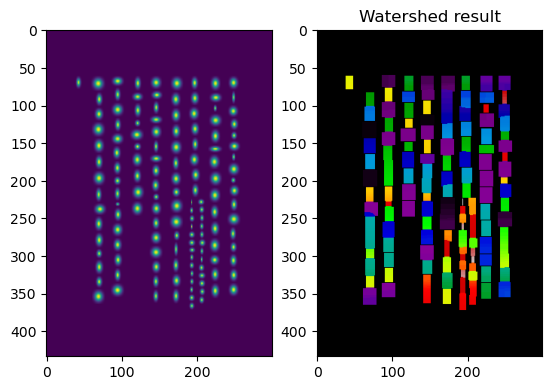

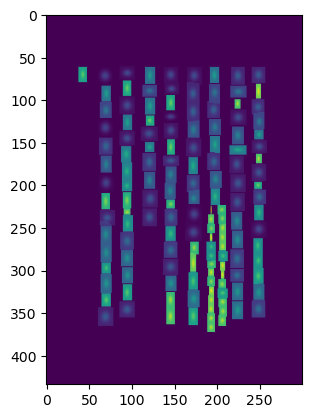

In [37]:
import numpy as np
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import label
from scipy import ndimage as ndi

# arr: (H, W) の2値画像
distance = ndi.distance_transform_edt(arr > 0)

# 局所最大値の座標リストを取得
coordinates = peak_local_max(distance, labels=(arr > 0), footprint=np.ones((3, 3)))

# マーカー画像を作成
markers = np.zeros_like(distance, dtype=np.int32)
for i, (y, x) in enumerate(coordinates, 1):
    markers[y, x] = i

# ウォーターシェッド
labels_ws = watershed(-distance, markers, mask=(arr > 0))

# 可視化
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.imshow(tmp_tar_image.cpu().numpy())
plt.subplot(1,2,2)
plt.imshow(labels_ws, cmap='nipy_spectral')
plt.title("Watershed result")
plt.show()
combined_image = (tmp_tar_image.cpu().numpy() / 2) + (labels_ws / 1000)
plt.imshow(combined_image)
plt.show()  
